# LSN-0.1 — Orientation & Environment Setup

| | |
|---|---|
| **Lesson** | `LSN-0.1` — Module `MOD-0` (Foundations), Week 1 |
| **Serves** | `OUT-0.1` — *run Python + Jupyter locally and execute a notebook end to end* |
| **Verified by** | `ASM-0` — a screenshot of this notebook's final checkpoint summary is your setup evidence |
| **Lesson plan** | `program/lessons/LSN-0.1-orientation-environment-setup.md` |

This is the first notebook of the program, and it has one job: **prove your machine is ready** so that Week 2's
hands-on labs (`LSN-1.4` MNIST, `LSN-2.4` RAG, `LSN-3.4` agent) never fight your environment.

**How to run it:** `Run → Run All Cells`. Every checkpoint should end in a ✅. If one fails, the output tells you
where to look (`INSTALL_TROUBLESHOOTING.md`) — and a broken checkpoint is a *valid* session artifact: we fix
broken setups live in the triage segment.

**When you're done:** screenshot the **Checkpoint Summary** cell output near the bottom, then fill in the
**baseline self-rating** in the final cells.

## The program in one cell

Three pillars × three tiers. Basics (this month) is mandatory and complete — no pick-and-choose.

| | ML Literacy (~5% of program) | LLM Literacy | Agentic Systems (the lion's share) |
|---|---|---|---|
| **Basics — 4 weeks, ~34 h** | five ML jobs, metrics, train MNIST | how LLMs work, build a RAG | frameworks, clouds, build an agent |
| **Advanced — ~3 months** | curated self-study | graph RAG, fine-tuning | ship a real agentic capstone |
| **Expert — ~6 months** | — | build-from-scratch spirit | eval frameworks, harnesses, hardening |

The cadence for every lesson: **pre-work → session → homework**, and checkpoints `ASM-0`–`ASM-3` gate progression.
Full details: `program/program-spec.md`. Graduation hackathon: **week of Dec 14–18**.

## Checkpoint 1 — Python interpreter & virtual environment

Verifies you're running a modern Python **inside the project virtualenv** (`.venv`), not your system Python.
Why a venv matters: isolation, reproducibility, and a clean system — see `ACTIVATE_VENV.md`.

In [1]:
# stdlib sys (interpreter info), platform (OS info)
import sys
import platform

# CHECKS accumulates every checkpoint result; the summary cell reads it at the end.
CHECKS = {}

py_version = sys.version_info
in_venv = sys.prefix != sys.base_prefix  # True when a virtualenv is active
version_ok = py_version >= (3, 9)

print(f"Interpreter : {sys.executable}")
print(f"Python      : {platform.python_version()}")
print(f"Platform    : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Virtualenv  : {'active' if in_venv else 'NOT active'}")
print()

if version_ok and in_venv:
    print("[PASS] Checkpoint 1 — modern Python inside the project venv.")
elif version_ok:
    print("[WARN] Python version is fine, but no virtualenv is active.")
    print("       Activate it first (see ACTIVATE_VENV.md), then relaunch Jupyter from the repo root:")
    print("         source .venv/bin/activate    # macOS/Linux")
    print("         .venv\\Scripts\\Activate.ps1  # Windows PowerShell")
else:
    print(f"[FAIL] Python {platform.python_version()} is too old — this program needs 3.9+.")

CHECKS["1. Interpreter & venv"] = version_ok and in_venv

Interpreter : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training/.venv/bin/python
Python      : 3.12.13
Platform    : Darwin 25.5.0 (arm64)
Virtualenv  : active

[PASS] Checkpoint 1 — modern Python inside the project venv.


## Checkpoint 2 — Core imports

The exact triage checkpoint from the session plan: `import numpy, pandas, matplotlib` must succeed
(plus `seaborn`, used from `LSN-0.2` on). If anything fails here, `pip install -r requirements.txt`
didn't finish — `INSTALL_TROUBLESHOOTING.md` has the known fixes, and the session's triage segment exists
for exactly this.

In [2]:
# stdlib importlib (metadata for version reporting)
from importlib import metadata

core_packages = ["numpy", "pandas", "matplotlib", "seaborn"]
failures = []

for pkg in core_packages:
    try:
        __import__(pkg)
        print(f"[OK]   {pkg:<12} {metadata.version(pkg)}")
    except Exception as exc:  # broad by design: any import failure is triage material
        failures.append(pkg)
        print(f"[FAIL] {pkg:<12} {type(exc).__name__}: {exc}")

print()
if failures:
    print(f"[FAIL] Checkpoint 2 — missing: {', '.join(failures)}")
    print("       Fix: activate the venv, then `pip install -r requirements.txt`.")
    print("       Still broken? Copy this cell's output — that IS your pre-work artifact — ")
    print("       and see INSTALL_TROUBLESHOOTING.md.")
else:
    print("[PASS] Checkpoint 2 — all core libraries import cleanly.")

CHECKS["2. Core imports"] = not failures

[OK]   numpy        2.5.1


[OK]   pandas       3.0.5


[OK]   matplotlib   3.11.1


[OK]   seaborn      0.13.2

[PASS] Checkpoint 2 — all core libraries import cleanly.


## Checkpoint 3 — Compute & plot

Importing is necessary, not sufficient. This cell makes numpy compute, pandas hold a table, and matplotlib
render a figure — using your actual next four weeks as the data. If a chart appears below, your stack works
end to end.

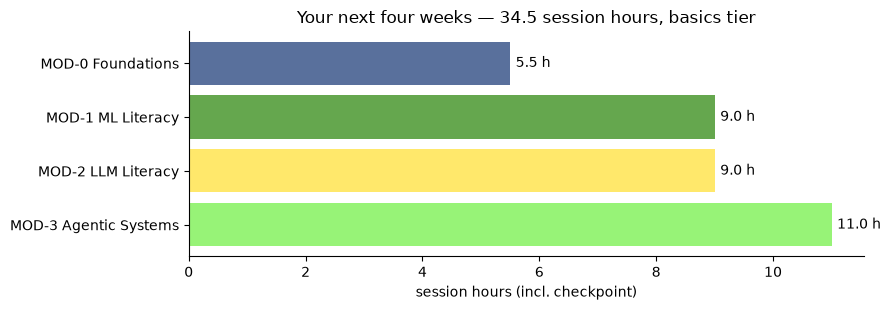

[PASS] Checkpoint 3 — computed with numpy, tabled with pandas, plotted with matplotlib.


In [3]:
# numpy (arrays/math), pandas (tables), matplotlib (plots)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

modules = pd.DataFrame({
    "module": ["MOD-0 Foundations", "MOD-1 ML Literacy", "MOD-2 LLM Literacy", "MOD-3 Agentic Systems"],
    "week": ["Week 1", "Weeks 1-2", "Weeks 2-3", "Weeks 3-4"],
    "session_hours": [5.5, 9.0, 9.0, 11.0],  # incl. checkpoints, from program/modules/README.md
})

total = modules["session_hours"].sum()
assert np.isclose(total, 34.5), "module hours drifted from the spec — check program/modules/README.md"

fig, ax = plt.subplots(figsize=(9, 3.2))
bars = ax.barh(modules["module"], modules["session_hours"], color=["#59709c", "#65a74e", "#ffe86b", "#97f377"])
ax.bar_label(bars, fmt="%.1f h", padding=4)
ax.invert_yaxis()
ax.set_xlabel("session hours (incl. checkpoint)")
ax.set_title(f"Your next four weeks — {total:.1f} session hours, basics tier")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"[PASS] Checkpoint 3 — computed with numpy, tabled with pandas, plotted with matplotlib.")
CHECKS["3. Compute & plot"] = True

## Checkpoint 4 — Repo layout

Confirms you're running from a complete clone: the materials every Week-1 lesson references must be where
the lessons expect them. (The walk-up-to-find-the-root logic mirrors `src/utils/pathing.py`, which the
foundations notebooks import.)

In [4]:
# stdlib pathlib (filesystem paths)
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory containing src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found — are you running inside the VSP-AI-ML-Training clone?")

repo_root = find_repo_root(Path.cwd())
print(f"Repo root: {repo_root}\n")

expected = [
    "ACTIVATE_VENV.md",
    "requirements.txt",
    "INSTALL_TROUBLESHOOTING.md",
    "notebooks/foundations/01_Beginning_Python.ipynb",
    "notebooks/foundations/02_Intermediate_Python.ipynb",
    "program/program-spec.md",
    "program/modules/module-0-foundations.md",
    "src/utils/pathing.py",
]

missing = []
for rel in expected:
    ok = (repo_root / rel).exists()
    print(f"[{'OK' if ok else 'MISSING'}]  {rel}")
    if not ok:
        missing.append(rel)

print()
if missing:
    print(f"[FAIL] Checkpoint 4 — incomplete clone ({len(missing)} missing). Re-clone or `git pull`.")
else:
    print("[PASS] Checkpoint 4 — every referenced material is where the lessons expect it.")

CHECKS["4. Repo layout"] = not missing

Repo root: /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training

[OK]  ACTIVATE_VENV.md
[OK]  requirements.txt
[OK]  INSTALL_TROUBLESHOOTING.md
[OK]  notebooks/foundations/01_Beginning_Python.ipynb
[OK]  notebooks/foundations/02_Intermediate_Python.ipynb
[OK]  program/program-spec.md
[OK]  program/modules/module-0-foundations.md
[OK]  src/utils/pathing.py

[PASS] Checkpoint 4 — every referenced material is where the lessons expect it.


## Checkpoint 5 — Later-module preview *(informational — never fails)*

The heavier libraries below aren't needed until the Week-2+ labs. This is a preview, not a gate: if some
say *not installed*, that's expected on a fresh core setup — the full `pip install -r requirements.txt`
brings them in, and `LSN-1.4` pre-work re-verifies before the MNIST lab.

In [5]:
# stdlib importlib.util (probe without importing — cheap and safe)
import importlib.util

preview = {
    "sklearn":               "LSN-1.2+ — model reference notebooks",
    "torch":                 "LSN-1.4 — MNIST hands-on lab",
    "transformers":          "LSN-2.1+ — LLM notebooks",
    "sentence_transformers": "LSN-2.3 — embeddings lab",
    "faiss":                 "LSN-2.4 — RAG vector store",
    "xgboost":               "advanced tier — ensemble references",
}

for pkg, needed_by in preview.items():
    installed = importlib.util.find_spec(pkg) is not None
    print(f"[{'installed    ' if installed else 'not installed'}]  {pkg:<22} needed by: {needed_by}")

print()
print("[PASS] Checkpoint 5 — informational only; nothing above blocks today.")
CHECKS["5. Later-module preview"] = True

[not installed]  sklearn                needed by: LSN-1.2+ — model reference notebooks
[not installed]  torch                  needed by: LSN-1.4 — MNIST hands-on lab
[not installed]  transformers           needed by: LSN-2.1+ — LLM notebooks
[not installed]  sentence_transformers  needed by: LSN-2.3 — embeddings lab
[not installed]  faiss                  needed by: LSN-2.4 — RAG vector store
[not installed]  xgboost                needed by: advanced tier — ensemble references

[PASS] Checkpoint 5 — informational only; nothing above blocks today.


## Checkpoint Summary — your `ASM-0` setup evidence

Run this cell, then **screenshot its output** (all five lines + the verdict). That screenshot is the setup
evidence `ASM-0` asks for. The cell also writes a machine-readable copy to `outputs/lsn-0.1/` — it stays on
your machine; the screenshot is what you submit.

In [6]:
# stdlib json (evidence file), datetime (timestamp), getpass/socket (who/where)
import json
import getpass
import socket
from datetime import datetime, timezone

print("=" * 62)
print("LSN-0.1 CHECKPOINT SUMMARY")
print("=" * 62)
for name, passed in CHECKS.items():
    print(f"  {'✅' if passed else '❌'}  {name}")
print("-" * 62)

all_passed = all(CHECKS.values())
stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
user, host = getpass.getuser(), socket.gethostname()

if all_passed:
    print(f"  ALL CHECKPOINTS PASSED — {user}@{host} — {stamp}")
    print("  📸 Screenshot this output — this is your ASM-0 setup evidence.")
else:
    failed = [n for n, p in CHECKS.items() if not p]
    print(f"  NOT DONE YET — failed: {', '.join(failed)} — {user}@{host} — {stamp}")
    print("  Bring this output to the triage segment; broken setups get fixed live.")
print("=" * 62)

evidence = {
    "lesson": "LSN-0.1", "verifies": "OUT-0.1", "assessment": "ASM-0",
    "user": user, "host": host, "timestamp_utc": stamp,
    "python": platform.python_version(), "virtualenv_active": in_venv,
    "checks": CHECKS, "all_passed": all_passed,
}
out_dir = repo_root / "outputs" / "lsn-0.1"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"setup_evidence_{user}.json"
out_path.write_text(json.dumps(evidence, indent=2))
print(f"Evidence file written: {out_path.relative_to(repo_root)}")

LSN-0.1 CHECKPOINT SUMMARY
  ✅  1. Interpreter & venv
  ✅  2. Core imports
  ✅  3. Compute & plot
  ✅  4. Repo layout
  ✅  5. Later-module preview
--------------------------------------------------------------
  ALL CHECKPOINTS PASSED — tylergoble@Tylers-MacBook-Pro.local — 2026-07-28 13:40 UTC
  📸 Screenshot this output — this is your ASM-0 setup evidence.
Evidence file written: outputs/lsn-0.1/setup_evidence_tylergoble.json


## Baseline self-rating

Rate yourself **1–5 on every basics outcome** below. Said explicitly, as in the session: **this is not a
filter** — nobody is scored on it. It's the baseline the program's lift is measured against at graduation
(see the Enrollment Gate in `program/program-spec.md`).

| Rating | Meaning |
|---|---|
| **1** | Never heard of it / couldn't say anything |
| **2** | Recognize the words; couldn't explain them |
| **3** | Could explain it to a colleague, roughly |
| **4** | Could use it in a client conversation today |
| **5** | Could teach this lesson |

**How:** replace each `0` with your honest 1–5, then run the cell. It refuses zeros and out-of-range
values, and writes your baseline to `outputs/lsn-0.1/` when complete.

In [7]:
# Replace each 0 with your honest 1-5 rating, then run this cell.
RATINGS = {
    # --- MOD-0 Foundations ---
    "OUT-0.1  Run Python + Jupyter locally; execute a notebook end to end": 0,
    "OUT-0.2  Explain deterministic vs probabilistic vs stochastic; read a confidence number": 0,
    "OUT-0.3  Reason about distributions, sampling, variance — 'how reliable is this answer?'": 0,
    "OUT-0.4  Spot correlation-vs-causation and small-sample traps": 0,
    # --- MOD-1 ML Literacy ---
    "OUT-1.1  Triage a client ask into the five ML jobs; ML vs generative AI": 0,
    "OUT-1.2  Say what each model type takes in / kicks out; interpret outputs": 0,
    "OUT-1.3  Read MAE, precision/recall, confusion matrix, AUC — 'good enough?'": 0,
    "OUT-1.4  Train a simple labeled model (MNIST) in a notebook": 0,
    "OUT-1.5  Hold a conversational exchange on NN / CNN / deep learning / RL": 0,
    "OUT-1.6  Articulate data requirements & ML limitations; run the question bank": 0,
    # --- MOD-2 LLM Literacy ---
    "OUT-2.1  Explain how an LLM works — tokens, training vs inference, hallucination": 0,
    "OUT-2.2  Prompt deliberately: system prompts, few-shot, CoT, structured outputs": 0,
    "OUT-2.3  Explain embeddings & vector search and where they fit": 0,
    "OUT-2.4  Sketch and defend a RAG architecture; build one": 0,
    "OUT-2.5  Choose prompt vs RAG vs fine-tune with cost/latency reasoning": 0,
    "OUT-2.6  State LLM limitations honestly; set survivable client expectations": 0,
    # --- MOD-3 Agentic Systems ---
    "OUT-3.1  Explain agents (tools, loops, harnesses); agent-vs-workflow judgment": 0,
    "OUT-3.2  Map the framework landscape and cloud offerings to use cases": 0,
    "OUT-3.3  Build a tool-calling agent end to end": 0,
    "OUT-3.4  Ask the production questions: observability, reliability, evals, KPIs, hardware, cost": 0,
    "OUT-3.5  Walk a real VSP case end to end, speaking both languages": 0,
}

unrated = [k.split()[0] for k, v in RATINGS.items() if v == 0]
invalid = [k.split()[0] for k, v in RATINGS.items() if v not in (0, 1, 2, 3, 4, 5)]

if invalid:
    print(f"[FIX] Ratings must be 1-5. Out of range: {', '.join(invalid)}")
elif unrated:
    print(f"[TODO] {len(unrated)} of {len(RATINGS)} outcomes still unrated: {', '.join(unrated)}")
    print("       Replace each 0 with your honest 1-5, then re-run this cell.")
else:
    baseline = {
        "lesson": "LSN-0.1", "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "scale": "1=never heard of it .. 5=could teach it",
        "ratings": {k.split()[0]: v for k, v in RATINGS.items()},
    }
    path = repo_root / "outputs" / "lsn-0.1" / f"baseline_selfrating_{getpass.getuser()}.json"
    path.write_text(json.dumps(baseline, indent=2))
    avg = sum(RATINGS.values()) / len(RATINGS)
    print(f"[SAVED] {path.relative_to(repo_root)}")
    print(f"        {len(RATINGS)} outcomes rated, average {avg:.1f}. See you at graduation for the delta.")

[TODO] 21 of 21 outcomes still unrated: OUT-0.1, OUT-0.2, OUT-0.3, OUT-0.4, OUT-1.1, OUT-1.2, OUT-1.3, OUT-1.4, OUT-1.5, OUT-1.6, OUT-2.1, OUT-2.2, OUT-2.3, OUT-2.4, OUT-2.5, OUT-2.6, OUT-3.1, OUT-3.2, OUT-3.3, OUT-3.4, OUT-3.5
       Replace each 0 with your honest 1-5, then re-run this cell.


## Wrap-up

**You're done when:** all five checkpoints show ✅, you have your summary screenshot, and your self-rating
is saved.

**Homework** (per the lesson plan): if you don't work in Python daily, complete
`notebooks/foundations/01_Beginning_Python.ipynb` end to end (and `02_Intermediate_Python.ipynb` as needed)
**before `LSN-1.4`** — the MNIST lab won't wait for syntax. Daily-Python folks: none.

**Next:** `LSN-0.2 — Statistics I` opens in a notebook and has ~30 min of pre-work. The pre-work rule from
today applies from here on: **no pre-work, no seat.**